# Climate Change Comment Sentiment Modeling 

**Goal:** Analyze sentiment in NASA climate change comments and build a clean, reproducible ML pipeline to classify comments into **Positive / Neutral / Negative**.

>  **Important note (weak supervision):** This dataset does not contain human-labeled sentiment.  
> We generate labels using **VADER** (lexicon-based sentiment). The model therefore learns to approximate VADER’s labeling rules, which is useful as a baseline and for workflow demonstration.  
> For production-grade sentiment, a **human-labeled validation set** is recommended.

---
## What this notebook covers
1. Problem + business context  
2. Data understanding & cleaning  
3. EDA (engagement + sentiment patterns)  
4. Feature engineering  
5. Train-test split (stratified)  
6. Modeling with a leakage-safe Pipeline  
7. Evaluation (macro F1, confusion matrix)  
8. Hyperparameter tuning
9. Error analysis  
10. Interpretable feature insights (per-class top terms)

## 1) Problem Statement

Given a collection of public comments from NASA’s climate change page, we want to:
- Understand how sentiment is distributed and how it changes over time.
- Build a supervised classification model to predict sentiment class from text + basic engagement features.

**Target:** `Sentiment` (Positive / Neutral / Negative), generated using VADER.

## 2) Business Understanding

A sentiment pipeline like this can help:
- Summarize public reaction to climate content and announcements.
- Track shifts in audience tone over time.
- Identify high-engagement discussions (likes/replies) and their sentiment.

**Practical value:** Communication teams can use these insights to shape messaging and monitor feedback patterns.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

nltk.download("vader_lexicon", quiet=True)

sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")

## 3) Data Loading & Understanding

We load the dataset and perform quick checks:
- Shape, schema, missing values
- Basic sanity checks on key columns

In [26]:
# Update this path if needed
DATA_PATH = "climate_nasa.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (522, 5)


,date,likesCount,profileName,commentsCount,text
0,2022-09-07T17:12:32.000Z,2,4dca617d86b3fdce80ba7e81fb16e048c9cd9798cdfd6d...,NaN,Neat comparison I have not heard it before.\n ...
1,2022-09-08T14:51:13.000Z,0,518ab97f2d115ba5b6f03b2fba2ef2b120540c9681288b...,NaN,An excellent way to visualise the invisible! T...
2,2022-09-07T17:19:41.000Z,1,d82e8e24eb633fd625b0aef9b3cb625cfb044ceb8483e1...,3.0,Does the CO2/ghg in the troposphere affect the...
3,2022-09-08T00:51:30.000Z,4,37a509fa0b5177a2233c7e2d0e2b2d6916695fa9fba3f2...,NaN,excellent post! I defo feel the difference - o...
4,2022-09-07T19:06:20.000Z,16,e54fbbd42a729af9d04d9a5cc1f9bbfe8081a31c219ecb...,26.0,"Yes, and carbon dioxide does not harm the Eart..."


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522 entries, 0 to 521
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           522 non-null    object 
 1   likesCount     522 non-null    int64  
 2   profileName    522 non-null    object 
 3   commentsCount  244 non-null    float64
 4   text           504 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 20.5+ KB


In [28]:
# Missing values overview
df.isnull().sum()

date               0
likesCount         0
profileName        0
commentsCount    278
text              18
dtype: int64

In [29]:
# Basic column validation
expected = {"date", "text", "likesCount", "commentsCount"}
missing = expected - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

## 4) Data Cleaning

Cleaning steps:
- Parse date into datetime
- Fill missing values in numeric engagement features
- Ensure text column is non-null

In [30]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

df["likesCount"] = df["likesCount"].fillna(0)
df["commentsCount"] = df["commentsCount"].fillna(0)
df["text"] = df["text"].fillna("")

df.head(2)

,date,likesCount,profileName,commentsCount,text
0,2022-09-07 17:12:32+00:00,2,4dca617d86b3fdce80ba7e81fb16e048c9cd9798cdfd6d...,0.0,Neat comparison I have not heard it before.\n ...
1,2022-09-08 14:51:13+00:00,0,518ab97f2d115ba5b6f03b2fba2ef2b120540c9681288b...,0.0,An excellent way to visualise the invisible! T...


## 5) Label Creation (Weak Supervision with VADER)

To generate a sentiment label from the raw comment text using VADER compound score:
- `compound >= 0.05` → Positive  
- `compound <= -0.05` → Negative  
- else → Neutral  

This provides a baseline target when human labels are not available.

In [31]:
sia = SentimentIntensityAnalyzer()

def vader_label(text: str) -> str:
    score = sia.polarity_scores(text)["compound"]
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["text"].apply(vader_label)

df["Sentiment"].value_counts()

Sentiment
Neutral     199
Positive    193
Negative    130
Name: count, dtype: int64

## 6) Exploratory Data Analysis (EDA)

Focus on EDA that directly supports modeling decisions:
- Class balance (impacts metric choice)
- Engagement distributions (heavy tails → log transforms)
- Relationship between likes and replies
- Sentiment patterns over time (proportion plot)

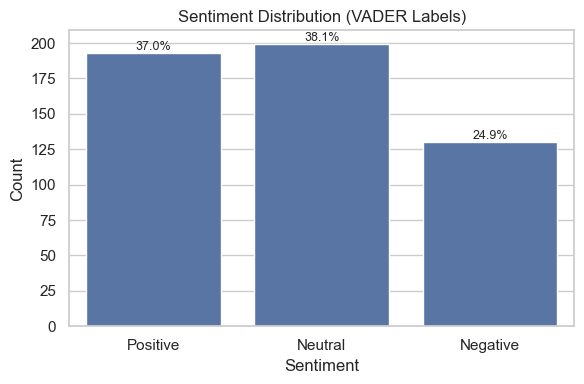

In [32]:
# Sentiment distribution (class balance)
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x="Sentiment", order=["Positive","Neutral","Negative"])
plt.title("Sentiment Distribution (VADER Labels)")
plt.xlabel("Sentiment")
plt.ylabel("Count")

# Add percentages on bars
total = len(df)
for p in ax.patches:
    pct = 100 * p.get_height() / total
    ax.annotate(f"{pct:.1f}%", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

The sentiment labels generated using VADER indicate that Neutral comments dominate slightly, while Positive and Negative sentiments are also well represented.
This balanced distribution helps reduce bias toward a single class during model training.
#####

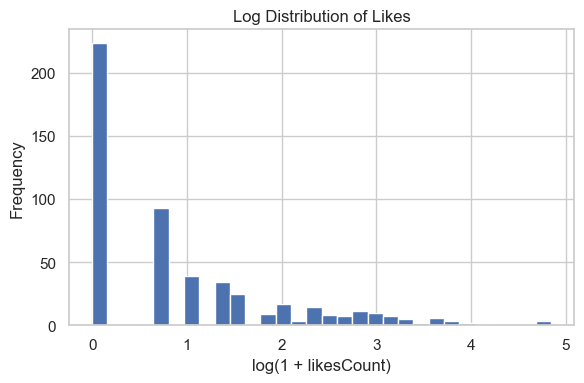

In [33]:
# Log distribution of likes (engagement is typically long-tailed)
plt.figure(figsize=(6,4))
plt.hist(np.log1p(df["likesCount"]), bins=30)
plt.title("Log Distribution of Likes")
plt.xlabel("log(1 + likesCount)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

The distribution of likes is highly right-skewed, with most comments receiving very few likes while a small number gain substantially higher engagement.
The log transformation helps reduce skewness and makes the distribution easier to analyze and more suitable for modeling.
#####

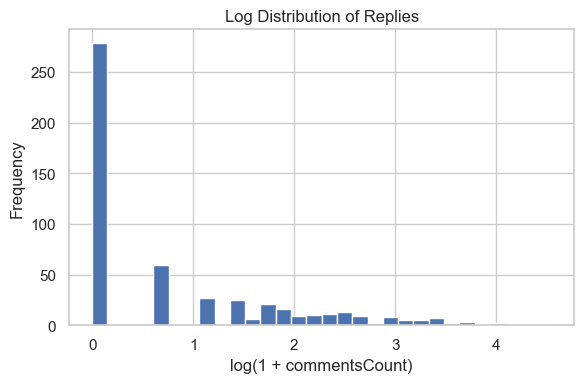

In [34]:
# Log distribution of replies
plt.figure(figsize=(6,4))
plt.hist(np.log1p(df["commentsCount"]), bins=30)
plt.title("Log Distribution of Replies")
plt.xlabel("log(1 + commentsCount)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


Similar to likes, reply counts are heavily skewed, with the majority of comments receiving little or no discussion.
A small number of comments generate significantly more replies, indicating occasional high-engagement discussions.
#####

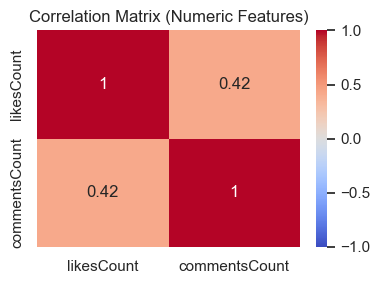

In [35]:
# Correlation between numeric features
numeric_cols = ["likesCount", "commentsCount"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(4,3))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()

Likes and comments show a moderate positive correlation (0.42), indicating that comments receiving more likes tend to also attract more replies.
However, the correlation is not strong enough to indicate redundancy, suggesting both features may contribute useful engagement information.
#####

<Figure size 1000x400 with 0 Axes>

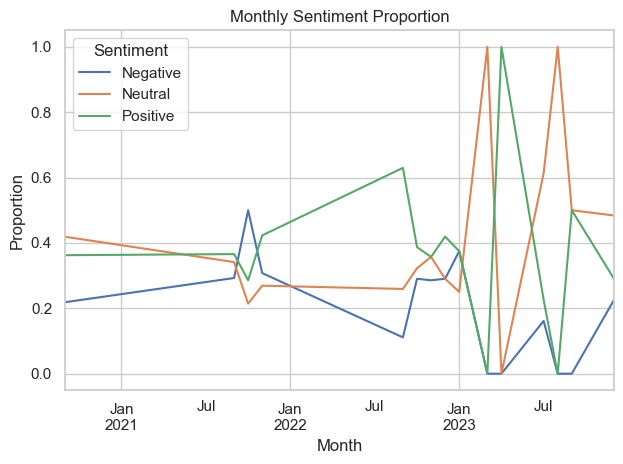

In [36]:
# Monthly sentiment proportion (time trend in proportions, not raw volume)
tmp = df.dropna(subset=["date"]).copy()
tmp["YearMonth"] = tmp["date"].dt.to_period("M")

monthly_counts = tmp.groupby(["YearMonth", "Sentiment"]).size().unstack().fillna(0)
monthly_prop = monthly_counts.div(monthly_counts.sum(axis=1), axis=0)

plt.figure(figsize=(10,4))
monthly_prop.plot()
plt.title("Monthly Sentiment Proportion")
plt.xlabel("Month")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

Sentiment proportions fluctuate over time, with Neutral sentiment remaining relatively stable while Positive and Negative sentiments vary across months.
These variations may reflect changing audience reactions to climate-related discussions or events during different periods.
#####

## 7) Feature Engineering

To create model-ready features:
- `CleanText`: light normalization (lowercase, remove URLs, normalize whitespace)
- `WordCount`: simple signal about comment length


In [37]:
import re

def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+", "", text)       # remove URLs
    text = re.sub(r"\s+", " ", text).strip()  # normalize whitespace
    return text

df["CleanText"] = df["text"].apply(clean_text)
df["WordCount"] = df["CleanText"].apply(lambda x: len(x.split()))

df[["CleanText","WordCount"]].head()

,CleanText,WordCount
0,neat comparison i have not heard it before. i ...,32
1,an excellent way to visualise the invisible! t...,8
2,does the co2/ghg in the troposphere affect the...,16
3,excellent post! i defo feel the difference - o...,19
4,"yes, and carbon dioxide does not harm the eart...",24


## 8) Train-Test Split (Stratified)

We use a **stratified split** to preserve the sentiment distribution in both train and test sets.  
This prevents accidental evaluation bias when classes are imbalanced.

In [38]:
X = df[["CleanText", "likesCount", "commentsCount", "WordCount"]]
y = df["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Train distribution:\n", y_train.value_counts(normalize=True).round(3))
print("Test distribution:\n", y_test.value_counts(normalize=True).round(3))

Train size: (417, 4)  Test size: (105, 4)
Train distribution:
 Sentiment
Neutral     0.381
Positive    0.369
Negative    0.249
Name: proportion, dtype: float64
Test distribution:
 Sentiment
Neutral     0.381
Positive    0.371
Negative    0.248
Name: proportion, dtype: float64


## 9) Modeling (Leakage-safe Pipeline)

We build a single `Pipeline` that:
- Vectorizes text with TF-IDF (ngrams)
- Scales numeric features
- Trains a Logistic Regression classifier

Using a pipeline ensures transformations are fit only on training data during CV, reducing leakage risk.

In [39]:
text_col = "CleanText"
num_cols = ["likesCount", "commentsCount", "WordCount"]

preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=3), text_col),
        ("num", StandardScaler(), num_cols)
    ],
    remainder="drop"
)

pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

### Baseline check

Before tuning anything, we compare against a **simple baseline**:

In [40]:
baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE))
])

baseline.fit(X_train, y_train)
base_pred = baseline.predict(X_test)
print("Baseline Macro F1:", f1_score(y_test, base_pred, average="macro"))

Baseline Macro F1: 0.1839080459770115


## 10) Evaluation (Initial Model)
- Macro F1 (fair across classes)
- Classification report
- Confusion matrix

Macro F1: 0.5327609304591402

Classification Report:

              precision    recall  f1-score   support

    Negative       0.75      0.23      0.35        26
     Neutral       0.60      0.78      0.67        40
    Positive       0.53      0.62      0.57        39

    accuracy                           0.58       105
   macro avg       0.63      0.54      0.53       105
weighted avg       0.61      0.58      0.56       105



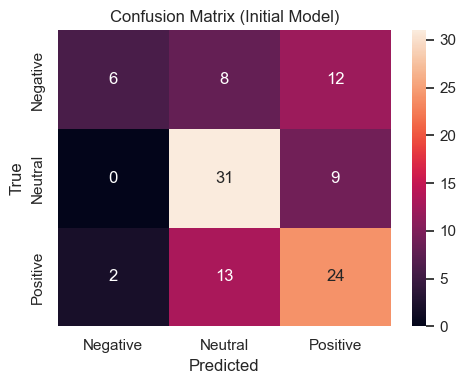

In [41]:
pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)

print("Macro F1:", f1_score(y_test, pred, average="macro"))
print("\nClassification Report:\n")
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred, labels=pipe.classes_)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=pipe.classes_, yticklabels=pipe.classes_)
plt.title("Confusion Matrix (Initial Model)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## 11) Hyperparameter Tuning
Tuning a small set of parameters that often matter most for TF-IDF + Logistic Regression:
- TF-IDF max features
- ngram range
- Logistic Regression regularization strength (`C`)

Using **StratifiedKFold** to preserve class distribution in each fold.

In [42]:
param_grid = {
    "preprocessor__text__max_features": [3000, 5000],
    "preprocessor__text__ngram_range": [(1,1), (1,2)],
    "clf__C": [0.1, 1, 5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    refit=True
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Macro F1:", grid.best_score_)

Best Params: {'clf__C': 5, 'preprocessor__text__max_features': 3000, 'preprocessor__text__ngram_range': (1, 2)}
Best CV Macro F1: 0.5836888920450939


## 12) Final Model Selection + Test Evaluation

Evaluating the best CV model once on the held-out test set.

Test Macro F1: 0.58182033854074

Classification Report:

              precision    recall  f1-score   support

    Negative       0.67      0.31      0.42        26
     Neutral       0.66      0.78      0.71        40
    Positive       0.57      0.67      0.61        39

    accuracy                           0.62       105
   macro avg       0.63      0.58      0.58       105
weighted avg       0.63      0.62      0.60       105



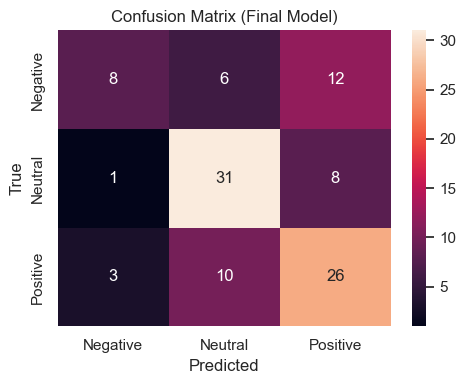

In [43]:
best_model = grid.best_estimator_
test_pred = best_model.predict(X_test)

print("Test Macro F1:", f1_score(y_test, test_pred, average="macro"))
print("\nClassification Report:\n")
print(classification_report(y_test, test_pred))

cm = confusion_matrix(y_test, test_pred, labels=best_model.classes_)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.title("Confusion Matrix (Final Model)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## 13)Error Analysis

This demonstrates:
- Practical debugging mindset
- Model understanding
- Better interview discussion

In [44]:
errors = X_test.copy()
errors["True"] = y_test.values
errors["Predicted"] = test_pred
errors["Correct"] = errors["True"] == errors["Predicted"]

misclassified = errors[~errors["Correct"]].copy()
misclassified.head(10)

,CleanText,likesCount,commentsCount,WordCount,True,Predicted,Correct
407,"our planet, and especially earth's ecosystems,...",3,0.0,69,Negative,Positive,False
107,remember the planet that we live on also went ...,0,10.0,17,Neutral,Positive,False
236,james procak because the expanding heat allows...,1,0.0,58,Negative,Positive,False
224,by 'people' hope they refer to the big greedy ...,0,1.0,37,Neutral,Positive,False
309,save the planet 🌎,1,0.0,4,Positive,Neutral,False
300,humans we are terrible to our planet.,1,0.0,7,Negative,Neutral,False
386,there is no time 🌤️,0,0.0,5,Negative,Neutral,False
451,in our area of the country (pa) a lot of the s...,0,0.0,26,Neutral,Positive,False
434,great post nasa climate change. no doubt the f...,7,0.0,17,Positive,Negative,False
402,when will we all agree to just stop burning st...,0,0.0,17,Positive,Neutral,False


In [45]:
conf_pairs = (misclassified["True"] + " → " + misclassified["Predicted"]).value_counts()
conf_pairs.head(10)

Negative → Positive    12
Positive → Neutral     10
Neutral → Positive      8
Negative → Neutral      6
Positive → Negative     3
Neutral → Negative      1
Name: count, dtype: int64

## 14) Interpretable Feature Insights (Top Terms per Class)

For Logistic Regression, we can inspect model coefficients.  
In multiclass classification, coefficients exist **per class**.

We display top positive-weighted terms for each class.

In [46]:
# fitted pipeline
best_model = grid.best_estimator_ 

pre = best_model.named_steps["preprocessor"]
vec = pre.named_transformers_["text"]
clf = best_model.named_steps["clf"]

text_feature_names = vec.get_feature_names_out()
n_text = len(text_feature_names)

for i, label in enumerate(clf.classes_):
    coefs_text = clf.coef_[i][:n_text]          
    top_idx = np.argsort(coefs_text)[-12:]
    top_terms = [text_feature_names[j] for j in top_idx]

    print(f"\nTop text terms for class '{label}':")
    print(top_terms)


Top text terms for class 'Negative':
['fault', 'the temperature', 'if', 'people are', 'will', 'its', 'dont', 'that', 'die', 'scary', 'fake', 'no']

Top text terms for class 'Neutral':
['when', 'ya', 'it would', 'measure', 'average', 'check', 'the earth', 'what', 'caused', 'is not', 'thermometer', 'in']

Top text terms for class 'Positive':
['nasa', 'warmer', 'hope', 'oh', 'interesting', 'your', 'love', 'warm', 'thanks', 'excellent', 'like', 'great']


## 15) Conclusion

**What we achieved:**
- Built a complete end-to-end sentiment pipeline (data → EDA → features → model → evaluation)
- Used leakage-safe preprocessing via sklearn pipelines
- Evaluated with macro F1 and confusion matrix
- Added error analysis and interpretable term insights

**Key limitation:** labels are generated via VADER, not human ground truth.

---
## Summary

This project builds an internship-ready sentiment modeling pipeline on NASA climate change comments.  
It demonstrates structured EDA, reproducible preprocessing, a leakage-safe TF-IDF + Logistic Regression model, and fair evaluation using macro F1-score.  
The work includes error analysis and interpretable feature insights, making the model behavior explainable and interview-ready.